---

## NOTEBOOK 03 : DBSCAN - CLASSIFICATION AVEC DBSCAN

---

---

## Description

    Ce notebook constitue le livrable de la phase de modélisation du projet.
    Il est consacré à l'application de l'algorithme DBSCAN pour la classification des
    donnees et la détection des potentielles anomalies dans les transactions bancaires.

    OBJECTIFS:
    ----------
        - Entraîner un modèle DBSCAN sur les données nettoyées
        - Détecter les transactions potentiellement anormales
        - Analyser et visualiser les résultats
        - Interpréter les potentielles anomalies détectées
        - Sauvegarder le modèle pour une utilisation ultérieure

    CONTENU:
    --------
        1. Introduction théorique à DBSCAN
        2. Chargement et préparation des données
        3. Normalisation des variables
        4. Entraînement du modèle DBSCAN
        5. Évaluation et analyse des résultats
        6. Visualisation des Potentielles anomalies
        7. Export des Potentielles anomalies détectées
        8. Synthèse et recommandations

    PRÉREQUIS:
    ----------
        - Notebook 01 exécuté (données nettoyées disponibles)
        - Bibliothèques: pandas, numpy, matplotlib, seaborn, scikit-learn

---

### SECTION 1 : INTRODUCTION - RAPPEL THÉORIQUE

---

   #### 1.1. PRINCIPE DE L'ALGORITHME DBSCAN
   -----------------------------------------------
   DBSCAN (Density-Based Spatial Clustering of Applications with Noise) est un algorithme de
    clustering basé sur la densité des points.DBSCAN ne nécessite pas de
    spécifier le nombre de clusters à l’avance; à la place, il nécessite deux hyperparamètres propres :
    ε(epsilon) et minPts.

   FONDEMENT THÉORIQUE :

      - Les anomalies sont rares et différentes
      - La classification des points basee sur dansité peut nous aider et isole les arnomalies potentielles
      - L'algorithme construit des groupes ou clusters
      - Les anomalies ont la particulaté de ne pas etre dans aucun groupe

   #### 1.2. AVANTAGES DE L'APPROCHE
   -----------------------------
      - Non supervisé: ne nécessite pas de données étiquetées
      - Pas besoin de spécifier le nombre de clusters à l'avance
      - Détecte les formes de clusters arbitraires:pas besoin d’être sphériques
      - Gère bien le bruit et les outliers : robuste aux valeurs aberrantes  
      - Relativement efficace :Sa complexité moyenne est O(n log n) ou O(n2)

   #### 1.3. HYPERPARAMÈTRES CLÉS
   --------------------------
      ε(epsilon) : une distance rayonnant autour d’un point, définissant son voisinage immédiat (ε
        neighborhood)
      minPts : le nombre minimum de points requis dans le voisinage ε pour que l’on considère
        qu’un point est dans une région suffisamment dense.
      

   #### 1.4. INTERPRÉTATION DES RÉSULTATS
   ----------------------------------
      - Score = -1: Anomalie détectée
      - Score = 1: Transaction normale

---         

### Importation des bibliothèques

In [1]:
"""
2. IMPORTATION DES BIBLIOTHÈQUES
=================================

Cette section importe toutes les bibliothèques nécessaires pour:
    - La manipulation des données (pandas, numpy)
    - La visualisation (matplotlib, seaborn)
    - La modélisation (scikit-learn)
    - La gestion des fichiers (joblib, pathlib)
    - La gestion des avertissements (warnings)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import yaml
import sklearn  
from datetime import datetime
from pathlib import Path
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Configuration des warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Création des dossiers nécessaires
for folder in ['../models', '../results/figures', '../results/metrics']:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("="*60)
print("NOTEBOOK 03 : DBSCAN - CLASSIFICATION")
print("="*60)

print("\nBibliothèques importées avec succès")
print(f"   - Pandas: {pd.__version__}")
print(f"   - NumPy: {np.__version__}")
print(f"   - Matplotlib: {plt.matplotlib.__version__}")
print(f"   - Seaborn: {sns.__version__}")
print(f"   - Scikit-learn: {sklearn.__version__}")  
print(f"   - Joblib: {joblib.__version__}")

NOTEBOOK 03 : DBSCAN - CLASSIFICATION

Bibliothèques importées avec succès
   - Pandas: 2.3.3
   - NumPy: 2.2.5
   - Matplotlib: 3.10.7
   - Seaborn: 0.13.2
   - Scikit-learn: 1.7.2
   - Joblib: 1.5.3


In [2]:
"""
    Cette section charge le jeu de données nettoyé produit par le Notebook 01.
    Les données sont prêtes pour la modélisation.
"""

def load_cleaned_data(filepath: str) -> pd.DataFrame:
    """
    Charge le jeu de données nettoyé à partir d'un fichier CSV.
    
    Parameters
    ----------
    filepath : str
        Chemin vers le fichier CSV contenant les données nettoyées
        
    Returns
    -------
    pd.DataFrame
        DataFrame contenant les données nettoyées
        
    Raises
    ------
    FileNotFoundError
        Si le fichier spécifié n'existe pas
        
    Examples
    --------
    >>> df = load_cleaned_data('../data/processed/indian_banking_transactions_clean.csv')
    >>> print(df.shape)
    (550000, 20)
    
    Notes
    -----
    Cette fonction suppose que les données ont déjà été nettoyées
    et sont prêtes pour la modélisation.
    """
    
    try:
        df = pd.read_csv(filepath)
        print(f"Données chargées avec succès")
        print(f"   - Fichier: {filepath}")
        print(f"   - Dimensions: {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
        return df
    except FileNotFoundError:
        print(f"Erreur: Fichier non trouvé à {filepath}")
        raise
    except Exception as e:
        print(f"Erreur lors du chargement: {str(e)}")
        raise

# Chargement des données
DATA_PATH = '../data/processed/indian_banking_transactions_clean.csv'

try:
    df = load_cleaned_data(DATA_PATH)
    print("\nAperçu des 5 premières lignes:")
    display(df.head())
except Exception as e:
    print(f"Erreur de chargement: {e}")
    df = pd.DataFrame()


Données chargées avec succès
   - Fichier: ../data/processed/indian_banking_transactions_clean.csv
   - Dimensions: 550,000 lignes x 20 colonnes

Aperçu des 5 premières lignes:


,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour
0,TXN000000001,CUST015796,2019-01-01,15:28,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,Unknown,0.00,Success,Branch,Verified,0,15
1,TXN000000002,CUST000861,2019-01-01,03:00,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,Unknown,0.00,Success,Mobile_App,Verified,0,3
2,TXN000000003,CUST076821,2019-01-01,18:03,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18
3,TXN000000004,CUST054887,2019-01-01,08:03,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8
4,TXN000000005,CUST006266,2019-01-01,14:23,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,Unknown,0.00,Success,API,Verified,0,14


In [3]:
"""

    Cette section sélectionne les variables numériques qui seront utilisées
    pour la détection d'anomalies.

    VARIABLES SÉLECTIONNÉES:
        - transaction_amount: Montant de la transaction
        - account_balance: Solde du compte
        - credit_score: Score de crédit du client
        - has_loan: Présence d'un prêt (0/1)
        - emi_amount: Montant des mensualités
        - transaction_hour: Heure de la transaction

    JUSTIFICATION DU CHOIX:
        - Variables quantitatives continues ou discrètes
        - Variables pertinentes pour la détection d'anomalies
        - Absence de valeurs manquantes significatives
        - Indépendance relative (corrélations faibles)
"""

def select_features(df: pd.DataFrame) -> tuple:
    """
    Sélectionne les variables numériques pour la modélisation.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contenant les données nettoyées
        
    Returns
    -------
    tuple
        - X: DataFrame contenant les variables sélectionnées
        - feature_names: Liste des noms des variables
        
    Examples
    --------
    >>> X, feature_names = select_features(df)
    >>> print(X.shape)
    (550000, 6)
    """

    feature_names = [
        'transaction_amount',
        'account_balance',
        'credit_score',
        'has_loan',
        'emi_amount',
        'transaction_hour'
    ]
    
    # Vérifier la présence des colonnes
    missing_cols = [col for col in feature_names if col not in df.columns]
    if missing_cols:
        print(f"Colonnes manquantes: {missing_cols}")
        raise ValueError(f"Colonnes manquantes: {missing_cols}")
    
    X = df[feature_names].copy()
    print(f"\nMatrice X: {X.shape[0]:,} lignes x {X.shape[1]} colonnes")
    print("\nVariables sélectionnées:")
    for i, feat in enumerate(feature_names, 1):
        print(f"   {i}. {feat}")
    
    return X, feature_names

X, feature_names = select_features(df)


Matrice X: 550,000 lignes x 6 colonnes

Variables sélectionnées:
   1. transaction_amount
   2. account_balance
   3. credit_score
   4. has_loan
   5. emi_amount
   6. transaction_hour


### SECTION 5 : NORMALISATION DES DONNÉES (STANDARD SCALER)

In [4]:
"""
    Cette section applique une transformation logarithmique pour réduire
    l'asymétrie des données avant la normalisation.

    RAISON DE LA LOG-TRANSFORMATION:
        - Réduire l'asymétrie des distributions (skewness)
        - Stabiliser la variance
        - Réduire l'impact des valeurs extrêmes (outliers)
        - Améliorer la performance des algorithmes

    VARIABLES TRANSFORMÉES:
        - transaction_amount: log(1 + amount)
        - account_balance: log(1 + balance)
        - emi_amount: log(1 + emi) (si présente)

    MÉTHODE: np.log1p(x) = log(1 + x)
        - Évite les problèmes avec log(0)
        - Préserve l'ordre des valeurs
"""

def normalize_data(X: pd.DataFrame) -> tuple:
    """
    Applique une transformation logarithmique sur les montants/soldes 
    puis normalise les données en utilisant StandardScaler.
    
    Parameters
    ----------
    X : pd.DataFrame
        DataFrame contenant les variables à transformer et normaliser
        
    Returns
    -------
    tuple
        - X_scaled: Array numpy des données transformées et normalisées
        - scaler: Objet StandardScaler ajusté
        
    Notes
    -----
    La transformation log1p est appliquée sur:
        - transaction_amount
        - account_balance
        - emi_amount (si présente)
        
    Examples
    --------
    >>> X_scaled, scaler = normalize_data(X)
    >>> print(X_scaled.mean())
    0.0
    """
    
    # Copie pour éviter de modifier l'original
    X_transformed = X.copy()
    
    print("\n" + "="*60)
    print("5. TRANSFORMATION LOG + NORMALISATION")
    print("="*60)
    
    # Variables à transformer
    log_vars = ['transaction_amount', 'account_balance']
    if 'emi_amount' in X_transformed.columns:
        log_vars.append('emi_amount')
    
    print("\nVariables transformées par log1p:")
    for var in log_vars:
        print(f"   - {var}")
    
    # Application de la transformation log1p
    for var in log_vars:
        X_transformed[var] = np.log1p(X_transformed[var])
    
    # Statistiques avant normalisation
    print("\nStatistiques après transformation log1p:")
    for var in log_vars:
        print(f"   - {var}: min={X_transformed[var].min():.4f}, "
              f"max={X_transformed[var].max():.4f}, "
              f"mean={X_transformed[var].mean():.4f}")
    
    # Normalisation StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_transformed)
    
    print("\nStatistiques après StandardScaler:")
    print(f"   - Moyenne globale: {X_scaled.mean():.6f}")
    print(f"   - Écart-type global: {X_scaled.std():.6f}")
    
    # Sauvegarder le scaler
    joblib.dump(scaler, '../models/scalerdb.pkl')
    print("\nScaler sauvegardé: '../models/scalerdb.pkl'")
    
    # Sauvegarder les noms des colonnes transformées
    with open('../models/transformed_featuresdb.txt', 'w') as f:
        f.write("Variables transformées par log1p:\n")
        for var in log_vars:
            f.write(f"  - {var}\n")
    
    return X_scaled, scaler

# Appel de la fonction de normalisation
X_scaled, scaler = normalize_data(X)


5. TRANSFORMATION LOG + NORMALISATION

Variables transformées par log1p:
   - transaction_amount
   - account_balance
   - emi_amount

Statistiques après transformation log1p:
   - transaction_amount: min=1.2238, max=16.1181, mean=7.9744
   - account_balance: min=6.2166, max=15.4249, mean=10.5024
   - emi_amount: min=0.0000, max=11.9403, mean=2.9717

Statistiques après StandardScaler:
   - Moyenne globale: -0.000000
   - Écart-type global: 1.000000

Scaler sauvegardé: '../models/scalerdb.pkl'


### SECTION 6: REDUCTION DE DIMENSIONNALITE-ACP

In [5]:
"""
Cette section applique l'Analyse en Composantes Principales (ACP) avant DBSCAN.
DBSCAN repose sur la distance entre transactions. Le nombre de
composantes est donc choisi automatiquement afin de préserver 99 % de la variance
tout en limitant l'effet de la dimensionnalité. Deux composantes ne serviront
ultérieurement qu'à la visualisation, et non à l'entraînement par défaut.

"""

def reduce_dimensions_acp(X_scaled: np.ndarray, config_path: str = '../configs/config.yml') -> tuple:

    """
    Projette les données normalisées dans l'espace ACP configuré.

    Returnes
    
    tuple
        X_reduced : données projetées pour DBSCAN
        pca : objet ACP ajusté, utile pour la traçabilité
    """
    variance_threshold = 0.99  # Compromis usuel : information conservée / simplicité.
    try:
        with open(config_path, 'r', encoding='utf-8') as file:
            pca_config = (yaml.safe_load(file) or {}).get('pca', {})
        variance_threshold = pca_config.get('variance_threshold', variance_threshold)
    except FileNotFoundError:
        print('Configuration ACP introuvable : conservation de 99 % de la variance.')

    if not 0 < variance_threshold <= 1:
        raise ValueError('pca.variance_threshold doit être compris entre 0 et 1.')

    print('\n' + '=' * 60)
    print('6. RÉDUCTION DE DIMENSIONNALITÉ PAR ACP')
    print('=' * 60)
    # Avec un seuil entre 0 et 1, sklearn choisit le nombre minimal de composantes.
    pca = PCA(n_components=variance_threshold, svd_solver='full')
    X_reduced = pca.fit_transform(X_scaled)
    pca.variance_threshold_ = variance_threshold

    print(f'Seuil de variance demandé : {variance_threshold:.0%}')
    print(f'Composantes retenues automatiquement : {pca.n_components_}')
    print(f'Variance expliquée cumulée : {pca.explained_variance_ratio_.sum() * 100:.2f}%')
    print(f'Nouvelle matrice : {X_reduced.shape[0]:,} lignes x {X_reduced.shape[1]} composantes')

    joblib.dump(pca, '../models/pca_dbscan.pkl')
    print("ACP sauvegardée : '../models/pca_dbscan.pkl'")
    return X_reduced, pca


X_reduced, pca_model = reduce_dimensions_acp(X_scaled)



6. RÉDUCTION DE DIMENSIONNALITÉ PAR ACP
Seuil de variance demandé : 99%
Composantes retenues automatiquement : 5
Variance expliquée cumulée : 99.89%
Nouvelle matrice : 550,000 lignes x 5 composantes
ACP sauvegardée : '../models/pca_dbscan.pkl'


#### 6.1. Visualisation de l'ACP

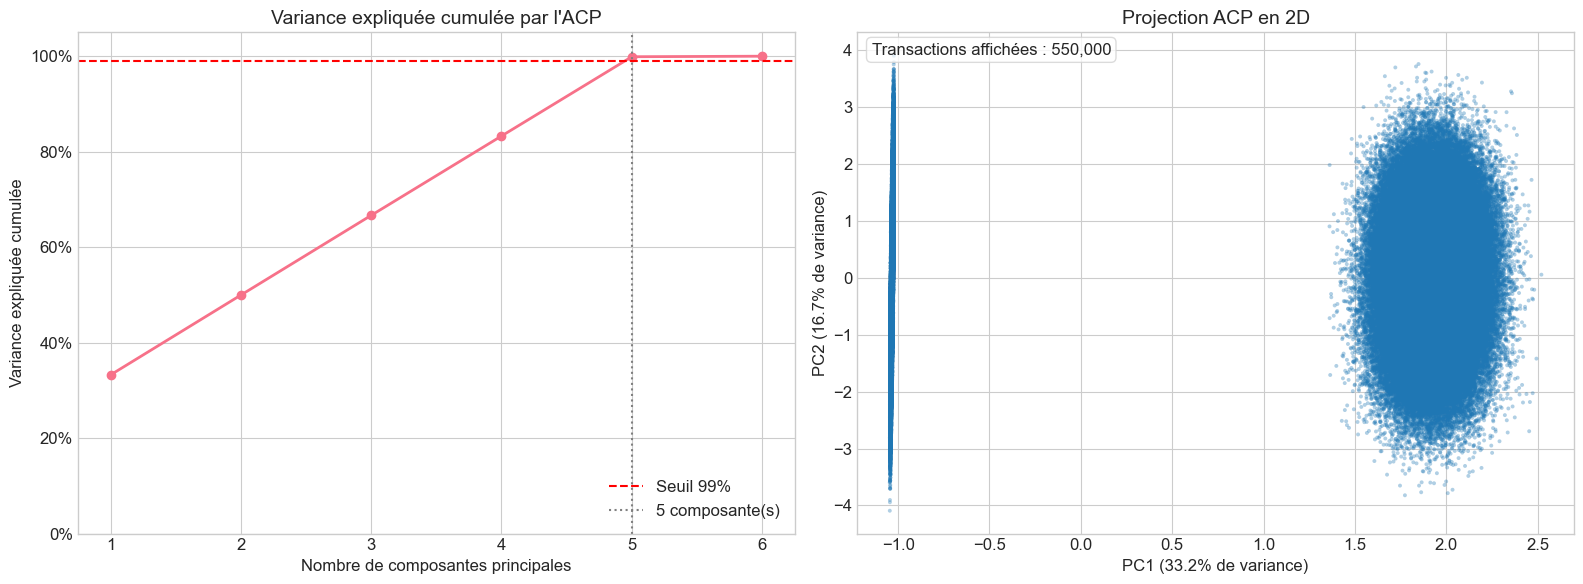

Visualisations ACP sauvegardées : '../results/figures/acp_variance_projection_2d.png'


In [6]:
"""
Dans cette section, pour justifier le nombre de composantes retenues, 
on visualise la variance expliquée cumulée. On affiche aussi une projection
en 2D sur les deux premières composantes principales afin d'observer la structure
globale des transactions dans l'espace ACP.
"""
def visualize_acp_results(
    X_scaled: np.ndarray,
    X_reduced: np.ndarray,
    pca_model: PCA,
    sample_size: int = 550000,
    random_state: int = 42
) -> None:
    
    """
        Affiche la variance expliquée cumulée et la projection ACP en 2D.
    """
    variance_threshold = getattr(
        pca_model,
        'variance_threshold_',
        pca_model.explained_variance_ratio_.sum()
    )

    # ACP complète pour visualiser la contribution de toutes les composantes disponibles.
    pca_full = PCA(svd_solver='full')
    pca_full.fit(X_scaled)
    explained_variance = pca_full.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    component_numbers = np.arange(1, len(cumulative_variance) + 1)
    n_components_threshold = int(np.searchsorted(cumulative_variance, variance_threshold) + 1)

    if X_reduced.shape[1] >= 2:
        projection_2d = X_reduced[:, :2]
        pc1_variance, pc2_variance = pca_model.explained_variance_ratio_[:2]
    else:
        pca_2d = PCA(n_components=2, svd_solver='full')
        projection_2d = pca_2d.fit_transform(X_scaled)
        pc1_variance, pc2_variance = pca_2d.explained_variance_ratio_

    if len(projection_2d) > sample_size:
        rng = np.random.default_rng(random_state)
        sample_index = rng.choice(len(projection_2d), size=sample_size, replace=False)
        projection_plot = projection_2d[sample_index]
        sample_note = f'Echantillon affiché : {sample_size:,} / {len(projection_2d):,} transactions'
    else:
        projection_plot = projection_2d
        sample_note = f'Transactions affichées : {len(projection_2d):,}'

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].plot(component_numbers, cumulative_variance, marker='o', linewidth=2)
    axes[0].axhline(variance_threshold, color='red', linestyle='--', linewidth=1.5,
                    label=f'Seuil {variance_threshold:.0%}')
    axes[0].axvline(n_components_threshold, color='gray', linestyle=':', linewidth=1.5,
                    label=f'{n_components_threshold} composante(s)')
    axes[0].set_title('Variance expliquée cumulée par l\'ACP')
    axes[0].set_xlabel('Nombre de composantes principales')
    axes[0].set_ylabel('Variance expliquée cumulée')
    axes[0].set_xticks(component_numbers)
    axes[0].set_ylim(0, 1.05)
    y_ticks = np.linspace(0, 1, 6)
    axes[0].set_yticks(y_ticks)
    axes[0].set_yticklabels([f'{value:.0%}' for value in y_ticks])
    axes[0].legend(loc='lower right')

    axes[1].scatter(
        projection_plot[:, 0],
        projection_plot[:, 1],
        s=8,
        alpha=0.35,
        color='#1f77b4',
        edgecolors='none'
    )
    axes[1].set_title('Projection ACP en 2D')
    axes[1].set_xlabel(f'PC1 ({pc1_variance:.1%} de variance)')
    axes[1].set_ylabel(f'PC2 ({pc2_variance:.1%} de variance)')
    axes[1].text(
        0.02, 0.98, sample_note,
        transform=axes[1].transAxes,
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgray')
    )

    plt.tight_layout()
    plt.savefig('../results/figures/acp_variance_projection_2d.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Visualisations ACP sauvegardées : '../results/figures/acp_variance_projection_2d.png'")


visualize_acp_results(X_scaled, X_reduced, pca_model)


### SECTION 7 : CONFIGURATION DU MODÈLE DBSCAN

Configuration chargée avec succès
Candidats min_samples chargés : [5, 10, 15, 20]

7. CALIBRATION DBSCAN PAR LES K-DISTANCES
Calcul des k-distances pour min_samples=5...
Calcul des k-distances pour min_samples=10...
Calcul des k-distances pour min_samples=15...
Calcul des k-distances pour min_samples=20...


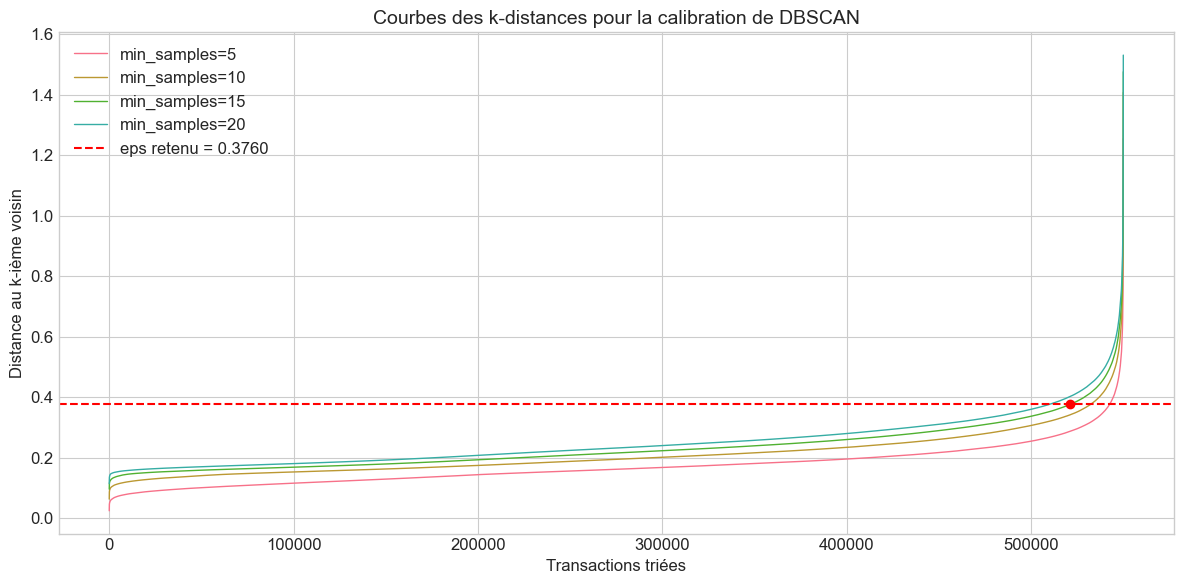


Paramètres retenus : min_samples=15, eps=0.3760
Graphique sauvegardé : '../results/figures/dbscan_k_distances.png'

Paramètres du modèle DBSCAN :
   - metric: euclidean
   - min_samples_candidates: [5, 10, 15, 20]
   - min_samples: 15
   - eps: 0.37600481112904327


In [7]:
"""
    
    Cette section charge et complète la configuration DBSCAN.
    Les hyperparamètres eps et min_samples ne sont pas fixés a priori, ils sont
    calibrés ci-dessous par les courbes des k-distances sur toutes les données ACP.

"""

def load_dbscan_config(config_path: str = '../configs/config.yml') -> tuple:

    """
        Charge les paramètres DBSCAN avec des valeurs par défaut sûres.

        retournes:
            tuple: config , dbscan_config

    """

    defaults = {
        'metric': 'euclidean',
        'min_samples_candidates': [5, 10, 15, 20]
    }

    try:
        with open(config_path, 'r', encoding='utf-8') as file:
            config = yaml.safe_load(file) or {}
        print('Configuration chargée avec succès')
    except FileNotFoundError:
        print(f'Fichier de configuration non trouvé : {config_path}')
        print('Utilisation des paramètres par défaut')
        config = {}

    dbscan_config = {**defaults, **config.get('dbscan', {})}
    candidates = dbscan_config['min_samples_candidates']
    if not all(isinstance(value, int) and value >= 2 for value in candidates):
        raise ValueError('Chaque candidat min_samples doit être un entier supérieur ou égal à 2.')
    print(f"Candidats min_samples chargés : {candidates}")

    return config, dbscan_config


def _find_knee(sorted_distances: np.ndarray) -> tuple:

    """
        Détecte le coude maximal par sa distance à la droite des extrémités.

        retournes:
            tuple: knee_index, distances_to_line
    """
    x = np.linspace(0, 1, len(sorted_distances))
    y_range = sorted_distances[-1] - sorted_distances[0]
    y = (sorted_distances - sorted_distances[0]) / y_range if y_range else np.zeros_like(x)
    # La distance a cette droite est maximale au changement de pente (le coude).
    distances_to_line = np.abs(y - x) / np.sqrt(2)
    knee_index = int(np.argmax(distances_to_line))

    return knee_index, float(distances_to_line[knee_index])


def calibrate_dbscan_kdistances(X_reduced: np.ndarray, config: dict) -> dict:
    
    """ 
        Cette fonction  choisit min_samples et eps à partir des k-distances calculées sur toutes les lignes.
        Pour chaque valeur candidate de min_samples, la distance au k-ième voisin est triée.
        La valeur candidate dont la courbe présente le coude le plus net est retenu, eps est
        alors égal à la k-distance située à ce coude.

        retourne:
            dict: config
    """

    print('\n' + '=' * 60)
    print('7. CALIBRATION DBSCAN PAR LES K-DISTANCES')
    print('=' * 60)

    candidates = sorted(set(config['min_samples_candidates']))
    candidates = [value for value in candidates if value <= len(X_reduced)]
    if not candidates:
        raise ValueError('Aucun candidat min_samples n’est compatible avec la taille des données.')

    curves, results = {}, []
    for min_samples in candidates:
        print(f'Calcul des k-distances pour min_samples={min_samples}...')
        neighbors = NearestNeighbors(
            n_neighbors=min_samples, metric=config['metric'], algorithm='ball_tree', n_jobs=-1
        ).fit(X_reduced)
        distances, _ = neighbors.kneighbors(X_reduced)
        k_distances = np.sort(distances[:, -1])
        knee_index, knee_strength = _find_knee(k_distances)
        curves[min_samples] = (k_distances, knee_index)
        results.append({
            'min_samples': min_samples,
            'eps': float(k_distances[knee_index]),
            'knee_strength': knee_strength
        })

    best = max(results, key=lambda result: result['knee_strength'])
    config['min_samples'] = best['min_samples']
    config['eps'] = best['eps']

    # graphique
    fig, ax = plt.subplots(figsize=(12, 6))
    _, best_knee_index = curves[config['min_samples']]
    for min_samples, (k_distances, _) in curves.items():
        ax.plot(k_distances, linewidth=1, label=f'min_samples={min_samples}')
    ax.axhline(config['eps'], color='red', linestyle='--',
               label=f"eps retenu = {config['eps']:.4f}")
    ax.scatter(best_knee_index, config['eps'], color='red', zorder=3)
    ax.set_title('Courbes des k-distances pour la calibration de DBSCAN')
    ax.set_xlabel('Transactions triées')
    ax.set_ylabel('Distance au k-ième voisin')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/figures/dbscan_k_distances.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nParamètres retenus : min_samples={config['min_samples']}, eps={config['eps']:.4f}")
    print("Graphique sauvegardé : '../results/figures/dbscan_k_distances.png'")

    return config


config, dbscan_config = load_dbscan_config()
dbscan_config = calibrate_dbscan_kdistances(X_reduced, dbscan_config)

print('\nParamètres du modèle DBSCAN :')
for key, value in dbscan_config.items():
    print(f'   - {key}: {value}')


### SECTION 8: ENTRAÎNEMENT DU MODÈLE

In [8]:


def train_dbscan(X_reduced: np.ndarray, config: dict) -> tuple:

    """
        Cette fonction entraîne DBSCAN sur les données déjà réduites par l'ACP.
        Le label -1 est le bruit selon DBSCAN, il est interprété ici
        comme une anomalie potentielle. Les autres labels correspondent à des groupes
        denses. 

        retournes:
          tuple: model, labels

    """
    print('\n' + '=' * 60)
    print('8. ENTRAÎNEMENT DU MODÈLE DBSCAN')
    print('=' * 60)

    print(f'Jeu complet utilisé pour DBSCAN : {len(X_reduced):,} transactions')

    # on passe les parametres à DBSCANB
    model = DBSCAN(
        eps=config['eps'],
        min_samples=config['min_samples'],
        metric=config['metric'],
        algorithm='ball_tree',
        n_jobs=-1
    )

    # on entraine le model
    print('\nEntraînement du modèle...')
    labels = model.fit_predict(X_reduced)

    n_anomalies = int(np.sum(labels == -1))
    n_clusters = len(set(labels)) - int(-1 in labels)
    pct_anomalies = n_anomalies / len(labels) * 100
    print('\n Résultats de la détection :')
    print(f'   Clusters denses détectés : {n_clusters:,}')
    print(f'   Transactions normales : {len(labels) - n_anomalies:,}')
    print(f'   Anomalies potentielles (bruit, label -1) : {n_anomalies:,} ({pct_anomalies:.2f}%)')

    # Le bundle conserve l'ACP et les paramètres calibrés pour assurer la traçabilité.
    artifact = {
        'dbscan_model': model,
        'pca': pca_model,
        'config': config,
        'feature_names': feature_names
    }
    joblib.dump(artifact, '../models/dbscan_acp.pkl')
    print("\nModèle et ACP sauvegardés : '../models/dbscan_acp.pkl'")

    return model, labels


dbscan_model, dbscan_labels = train_dbscan(
    X_reduced, dbscan_config
)



8. ENTRAÎNEMENT DU MODÈLE DBSCAN
Jeu complet utilisé pour DBSCAN : 550,000 transactions

Entraînement du modèle...

 Résultats de la détection :
   Clusters denses détectés : 4
   Transactions normales : 538,772
   Anomalies potentielles (bruit, label -1) : 11,228 (2.04%)

Modèle et ACP sauvegardés : '../models/dbscan_acp.pkl'


### SECTION 9 : VISUALISATION DES CLUSTERS DBSCAN

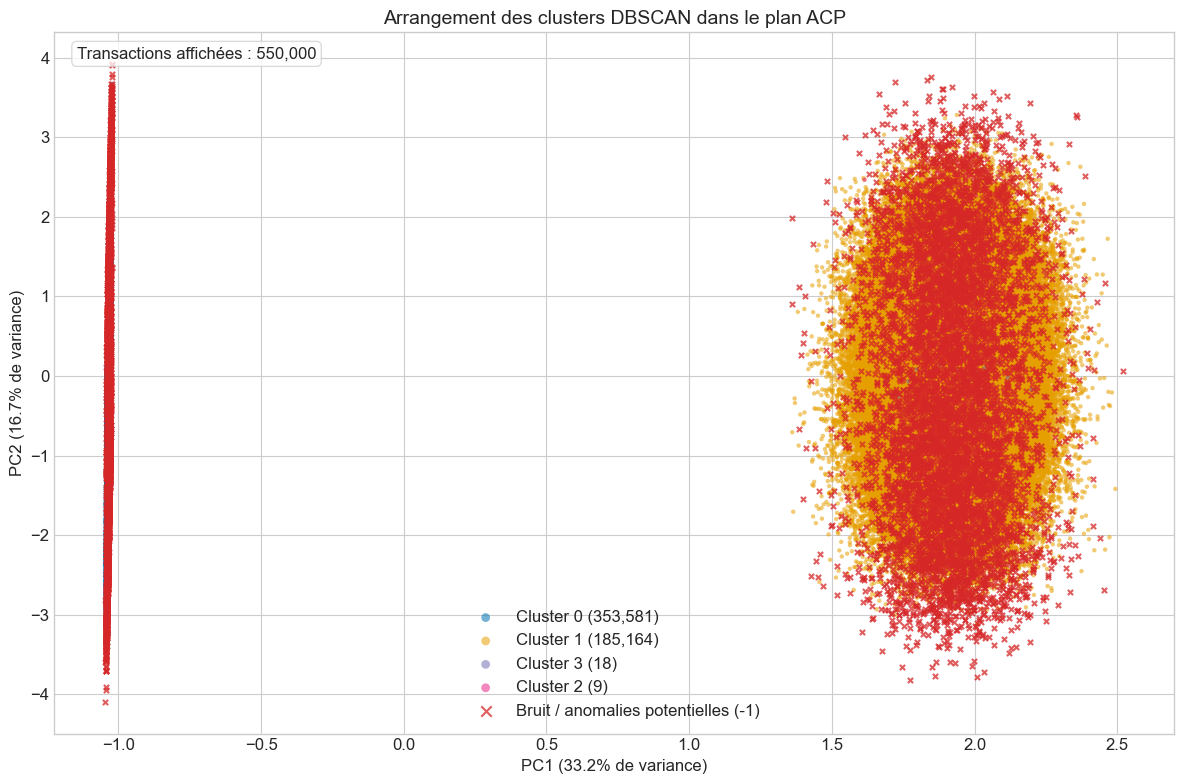

Visualisation des clusters sauvegardée : '../results/figures/dbscan_clusters_acp_2d.png'


In [9]:
"""
Cette visualisation projette les transactions sur les deux premières composantes principales
et colore les points selon le cluster attribué par DBSCAN. Le label -1 correspond au bruit,
 donc aux anomalies potentielles.
"""
def visualize_dbscan_clusters_2d(
    X_reduced: np.ndarray,
    labels: np.ndarray,
    pca_model: PCA,
    sample_size: int = 550000,
    random_state: int = 42
) -> None:
    
    """
    Affiche les clusters DBSCAN dans le plan ACP PC1-PC2.

    """
    labels = np.asarray(labels)
    if len(X_reduced) != len(labels):
        raise ValueError('X_reduced et labels doivent avoir le même nombre de lignes.')
    if X_reduced.shape[1] < 2:
        raise ValueError('La visualisation 2D nécessite au moins deux composantes ACP.')

    projection_2d = X_reduced[:, :2]
    pc1_variance, pc2_variance = pca_model.explained_variance_ratio_[:2]

    if len(labels) > sample_size:
        rng = np.random.default_rng(random_state)
        noise_index = np.flatnonzero(labels == -1)
        cluster_index = np.flatnonzero(labels != -1)

        if len(noise_index) > sample_size:
            sample_index = rng.choice(noise_index, size=sample_size, replace=False)
        else:
            remaining = sample_size - len(noise_index)
            cluster_sample = rng.choice(cluster_index, size=remaining, replace=False)
            sample_index = np.concatenate([noise_index, cluster_sample])
        sample_note = f'Echantillon affiché : {len(sample_index):,} / {len(labels):,} transactions'
    else:
        sample_index = np.arange(len(labels))
        sample_note = f'Transactions affichées : {len(labels):,}'

    projection_plot = projection_2d[sample_index]
    labels_plot = labels[sample_index]
    cluster_labels = sorted(label for label in np.unique(labels_plot) if label != -1)
    cluster_sizes = {label: int(np.sum(labels_plot == label)) for label in cluster_labels}
    clusters_by_size_desc = sorted(cluster_labels, key=lambda label: cluster_sizes[label], reverse=True)

    fig, ax = plt.subplots(figsize=(12, 8))
    cluster_colors = {
        0: '#0072B2',  
        1: '#E69F00',  
    }
    fallback_palette = sns.color_palette('Dark2', n_colors=max(len(cluster_labels), 1))

    for color_index, cluster_label in enumerate(clusters_by_size_desc):
        mask = labels_plot == cluster_label
        color = cluster_colors.get(cluster_label, fallback_palette[color_index % len(fallback_palette)])
        ax.scatter(
            projection_plot[mask, 0],
            projection_plot[mask, 1],
            s=10,
            alpha=0.55,
            color=color,
            edgecolors='none',
            label=f'Cluster {cluster_label} ({cluster_sizes[cluster_label]:,})'
        )

    noise_mask = labels_plot == -1
    if np.any(noise_mask):
        ax.scatter(
            projection_plot[noise_mask, 0],
            projection_plot[noise_mask, 1],
            s=14,
            alpha=0.75,
            color='#d62728',
            marker='x',
            label='Bruit / anomalies potentielles (-1)'
        )

    ax.set_title('Arrangement des clusters DBSCAN dans le plan ACP')
    ax.set_xlabel(f'PC1 ({pc1_variance:.1%} de variance)')
    ax.set_ylabel(f'PC2 ({pc2_variance:.1%} de variance)')
    ax.text(
        0.02, 0.98, sample_note,
        transform=ax.transAxes,
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgray')
    )
    ax.legend(loc='best', markerscale=2)

    plt.tight_layout()
    plt.savefig('../results/figures/dbscan_clusters_acp_2d.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Visualisation des clusters sauvegardée : '../results/figures/dbscan_clusters_acp_2d.png'")


visualize_dbscan_clusters_2d(X_reduced, dbscan_labels, pca_model)


### SECTION 10 : ANALYSE DES RÉSULTATS

In [10]:
"""

    Cette section analyse les résultats du modèle DBSCAN.

    INDICATEURS ANALYSÉS:
        - Nombre d'anomalie potentielle détectée
        - Proportion d'anomalies par rapport au total
        - Distribution des clusters DBSCAN
        - Statistiques des variables pour les anomalies vs normales
"""

def analyze_results(df: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    """
    Analyse les résultats du modèle modèle DBSCAN.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame original
    labels : np.ndarray
        Labels DBSCAN (-1 = bruit/anomalie potentielle, 0, 1, ... = clusters)
        
    Returns
    -------
    pd.DataFrame
        DataFrame original enrichi avec les labels DBSCAN.
        
    """
    
    print("\n" + "="*60)
    print("10. ANALYSE DES RÉSULTATS")
    print("="*60)
    
    labels = np.asarray(labels)
    if len(df) != len(labels):
        raise ValueError('df et labels doivent avoir le même nombre de lignes.')

    # Ajouter les labels DBSCAN au DataFrame
    df_result = df.copy()
    df_result['dbscan_cluster'] = labels
    df_result['dbscan_anomaly'] = np.where(labels == -1, -1, 1)
    
    # Séparer normales et anomalies
    normal = df_result[df_result['dbscan_anomaly'] == 1]
    anomalies = df_result[df_result['dbscan_anomaly'] == -1]
    
    print("\n8.1 STATISTIQUES GLOBALES:")
    print("-"*40)
    print(f"   - Total: {len(df_result):,}")
    print(f"   - Normales: {len(normal):,} ({len(normal)/len(df_result)*100:.2f}%)")
    print(f"   - Anomalies: {len(anomalies):,} ({len(anomalies)/len(df_result)*100:.2f}%)")
    print(f"   - Clusters denses détectés: {df_result.loc[df_result['dbscan_cluster'] != -1, 'dbscan_cluster'].nunique():,}")

    print("\n10.2 DISTRIBUTION DES CLUSTERS DBSCAN:")
    print("-"*40)
    cluster_distribution = (
        df_result['dbscan_cluster']
        .value_counts()
        .sort_index()
        .rename_axis('Cluster')
        .reset_index(name='Nombre')
    )
    cluster_distribution['Pourcentage'] = cluster_distribution['Nombre'] / len(df_result) * 100
    display(cluster_distribution.round(2))
    
    print("\n10.3 STATISTIQUES DES VARIABLES (ANOMALIES VS NORMALES):")
    print("-"*40)
    
    variables = ['transaction_amount', 'account_balance', 'credit_score', 'has_loan', 'emi_amount', 'transaction_hour']
    
    stats = []
    for var in variables:
        stats.append({
            'Variable': var,
            'Moyenne_Normal': normal[var].mean(),
            'Moyenne_Anomalie': anomalies[var].mean(),
            'Écart_Normal': normal[var].std(),
            'Écart_Anomalie': anomalies[var].std()
        })
    
    stats_df = pd.DataFrame(stats)
    display(stats_df.round(2))
    
    # Sauvegarde
    stats_df.to_csv('../results/metrics/dbscan_stats.csv', index=False)
    cluster_distribution.to_csv('../results/metrics/dbscan_cluster_distribution.csv', index=False)
    print("\nStatistiques sauvegardées : '../results/metrics/dbscan_stats.csv'")
    print("Distribution des clusters sauvegardée : '../results/metrics/dbscan_cluster_distribution.csv'")
    
    return df_result

df_result = analyze_results(df, dbscan_labels)


10. ANALYSE DES RÉSULTATS

8.1 STATISTIQUES GLOBALES:
----------------------------------------
   - Total: 550,000
   - Normales: 538,772 (97.96%)
   - Anomalies: 11,228 (2.04%)
   - Clusters denses détectés: 4

10.2 DISTRIBUTION DES CLUSTERS DBSCAN:
----------------------------------------


,Cluster,Nombre,Pourcentage
0,-1,11228,2.04
1,0,353581,64.29
2,1,185164,33.67
3,2,9,0.00
4,3,18,0.00



10.3 STATISTIQUES DES VARIABLES (ANOMALIES VS NORMALES):
----------------------------------------


,Variable,Moyenne_Normal,Moyenne_Anomalie,Écart_Normal,Écart_Anomalie
0,transaction_amount,23861.60,319998.12,84974.28,722785.42
1,account_balance,76952.55,449116.97,120207.01,775846.96
2,credit_score,599.76,601.96,172.91,179.86
3,has_loan,0.34,0.63,0.47,0.48
4,emi_amount,2317.88,4668.17,4893.41,7567.88
5,transaction_hour,11.51,11.38,6.92,7.13



Statistiques sauvegardées : '../results/metrics/dbscan_stats.csv'
Distribution des clusters sauvegardée : '../results/metrics/dbscan_cluster_distribution.csv'
